# 33 — The conviction field $U=\mathsf T u$ and the belief–utility balance

**Why this notebook exists (Plan P4).** Active inference already houses value: the preference
matrix $C$, read by Hyland & Albarracín as a *belief utility* — value attached to holding a
belief, over and above its accuracy. The paper puts that value on the **network**: the same
operator $\mathsf T=(I-\alpha W)^{-1}$ that propagates carry-over cost ($\kappa=\mathsf T\,1$,
the conservatism field) propagates the intrinsic utility too, giving the **conviction field**

$$U \;=\; \mathsf T\,u .$$

These are two source vectors through one operator — linearly independent unless $u\propto 1$.
The motivated agent minimizes $\mathcal F[q]=D_{\mathrm{KL}}[q\,\|\,p(s\mid o)]-\lambda\,
\mathbb E_q[U]$, whose minimizer is the value-tilted posterior $q_\lambda\propto p(s\mid o)\,
e^{\lambda U(s)}$. For a linear utility on a Gaussian this is exactly one shift of the
potential, $h\leftarrow h+\lambda U$, which is how we wire it into the population step.

**The knob is just a balance.** Following the project steer, $\lambda$ (the belief-utility
strength) is treated only as a *balance*: `balanced_lambda` picks the scale at which the
conviction's per-step potential matches the evidence's on the contested commitments, so
neither field dominates. Nothing deeper is built; we then read off the three regimes.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.config import NetworkConfig
from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, phlogiston as ph

NET = NetworkConfig(kind="watts_strogatz", mean_degree=4, rewiring_p=0.1)
# World held at the oxygen (true) regime; the population starts on the wrong (phlogiston)
# paradigm; pure evidence (no governance) would carry it to the truth. The conviction field
# is the only thing pulling back. (relational substrate, derived precision, gamma off.)
base = StructuralConfig(n_agents=48, n_steps=140, t_shift=0, observation_operator="relational",
                        precision_mode="derived", core_governance=0.0, network=NET)

def final_m(tilt=0.0, toward="phlogiston", n_seeds=4):
    cfg = dataclasses.replace(base, conviction_tilt=tilt, conviction_toward=toward)
    g = [{"count": cfg.n_agents, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass}]
    return np.mean([float(S.run_trace(cfg, S.init_state(cfg, jax.random.PRNGKey(s), groups=g))[0][-1])
                    for s in range(n_seeds)])

def traj(tilt, toward="phlogiston", seed=0):
    cfg = dataclasses.replace(base, conviction_tilt=tilt, conviction_toward=toward)
    g = [{"count": cfg.n_agents, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass}]
    return np.asarray(S.run_trace(cfg, S.init_state(cfg, jax.random.PRNGKey(seed), groups=g))[0])

lam = ph.balanced_lambda(base, toward="phlogiston")
print(f"balanced_lambda (toward phlogiston) = {lam:.3f}")

balanced_lambda (toward phlogiston) = 1.123


## §1 — The conviction field: value propagated along the net

The intrinsic utility $u$ (a community that *wants* the phlogiston reading: negative value on
the mass-law commitments) is a sparse source. The conviction field $U=\mathsf T u$ spreads it
along the paradigm's couplings — exactly as carry-over spreads the unit source. We plot both,
on the incumbent prior.

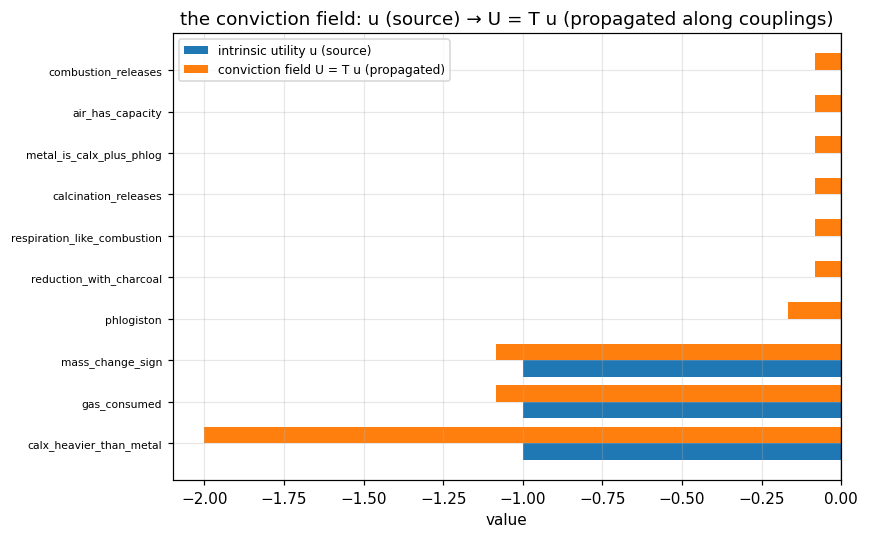

U on contested nodes: {'mass_change_sign': -1.08, 'gas_consumed': -1.08, 'calx_heavier_than_metal': -2.0}


In [2]:
net = ph.phlogiston_prior(base)
u = ph.conviction_u(base, "phlogiston")
U = np.asarray(ph.conviction_field(net.Pi[None], net.h[None], base.node_names, u, base.conviction_alpha)[0])
names = base.node_names
order = np.argsort(U)

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(names))
ax.barh(y - 0.2, [float(u[i]) for i in order], height=0.4, label='intrinsic utility u (source)')
ax.barh(y + 0.2, [U[i] for i in order], height=0.4, label='conviction field U = T u (propagated)')
ax.set_yticks(y); ax.set_yticklabels([names[i] for i in order], fontsize=7)
ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('value'); ax.legend(fontsize=8)
ax.set_title('the conviction field: u (source) → U = T u (propagated along couplings)')
plt.tight_layout(); plt.savefig('figures_nb33_field.png'); plt.show()
print('U on contested nodes:', {n: round(float(U[base.node_names.index(n)]), 2) for n in ph.DISAGREEMENT_NODES})

## §2 — The balance: sweeping the tilt through the three regimes

We sweep $\lambda$ in units of `balanced_lambda` (conviction toward the *wrong* paradigm, so
it opposes the oxygen evidence) and read the final population belief. At $\lambda=0$ the
evidence wins (truth, $m\to 1$); as $\lambda$ grows the conviction drags belief down; past a
crossover the value field overrides the evidence entirely (motivated lock-in, $m\to 0$). The
**balance** — neither field dominating — is the $m\approx\tfrac12$ crossing.

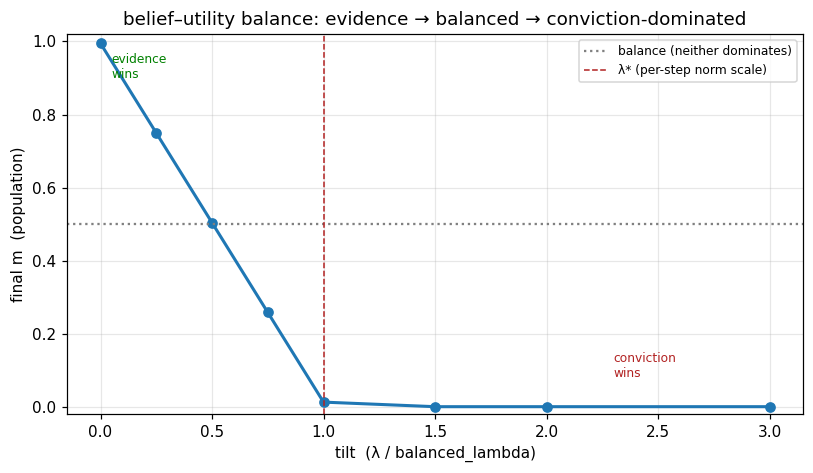

final m by tilt/λ*: {0.0: 0.99, 0.25: 0.75, 0.5: 0.5, 0.75: 0.26, 1.0: 0.01, 1.5: 0.0, 2.0: 0.0, 3.0: 0.0}
empirical 50/50 crossover ≈ 0.50·λ*  (< λ*: the coherent conviction punches above its per-step norm, as documented).


In [3]:
mults = np.array([0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0])
m_by = np.array([final_m(f * lam) for f in mults])
# linear-interpolate the empirical 50/50 crossover (in units of λ*)
cross_mult = float('nan')
for i in range(len(m_by) - 1):
    if m_by[i] >= 0.5 >= m_by[i + 1]:
        frac = (m_by[i] - 0.5) / (m_by[i] - m_by[i + 1] + 1e-12)
        cross_mult = float(mults[i] + frac * (mults[i + 1] - mults[i])); break

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(mults, m_by, 'o-', lw=2)
ax.axhline(0.5, color='grey', ls=':', label='balance (neither dominates)')
ax.axvline(1.0, color='firebrick', ls='--', lw=1, label='λ* (per-step norm scale)')
ax.set_xlabel('tilt  (λ / balanced_lambda)'); ax.set_ylabel('final m  (population)')
ax.set_ylim(-0.02, 1.02); ax.set_title('belief–utility balance: evidence → balanced → conviction-dominated')
ax.legend(fontsize=8)
ax.text(0.05, 0.9, 'evidence\nwins', fontsize=8, color='green')
ax.text(2.3, 0.08, 'conviction\nwins', fontsize=8, color='firebrick')
plt.tight_layout(); plt.savefig('figures_nb33_balance.png'); plt.show()
print('final m by tilt/λ*:', dict(zip(mults.tolist(), np.round(m_by, 2).tolist())))
print(f'empirical 50/50 crossover ≈ {cross_mult:.2f}·λ*  '
      f'(< λ*: the coherent conviction punches above its per-step norm, as documented).')

## §3 — The sign of the conviction sets the direction

The tilt is a *vector* field, not a scalar pressure: pointing it toward the truth (oxygen)
leaves the evidence-driven convergence intact, while pointing it at the falsehood
(phlogiston) is what drags belief away. Three runs at the same $|\lambda|=\lambda^\*$.

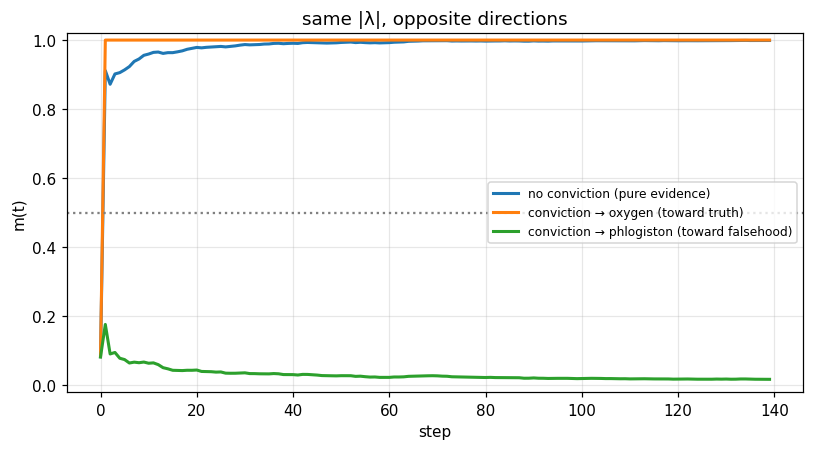

finals  | pure: 0.99  toward-oxygen: 1.0  toward-phlogiston: 0.01


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(traj(0.0), lw=2, label='no conviction (pure evidence)')
ax.plot(traj(lam, 'oxygen'), lw=2, label='conviction → oxygen (toward truth)')
ax.plot(traj(lam, 'phlogiston'), lw=2, label='conviction → phlogiston (toward falsehood)')
ax.axhline(0.5, color='grey', ls=':'); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('step'); ax.set_ylabel('m(t)'); ax.set_title('same |λ|, opposite directions')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb33_direction.png'); plt.show()
print('finals  | pure:', round(final_m(0.0),2),
      ' toward-oxygen:', round(final_m(lam,'oxygen'),2),
      ' toward-phlogiston:', round(final_m(lam,'phlogiston'),2))

## Verdict

The conviction field $U=\mathsf T u$ is in place as the network's second field — value
propagated by the *same* operator as carry-over, and linearly independent of it. Wired as the
Gaussian value-tilt $h\leftarrow h+\lambda U$, it does exactly what the belief-utility account
says: a community that *wants* a conclusion bends its posterior toward it, and at strong enough
$\lambda$ overrides reachable evidence (value-driven lock-in). The knob is, as intended, just a
**balance**: `balanced_lambda` is the principled per-step scale at which the two fields' potentials
match on the contested commitments; the dynamical 50/50 crossover sits a bit below it (the
coherent conviction outweighs the partly-cancelling evidence), reported rather than tuned away.

This closes the loop with nb32: γ (evidential silencing) and a strong conviction tilt are the
**two faces of motivated cognition** the paper unifies — the multiplicative bias (susceptibility
$Z''(\lambda)$, which silences disconfirming channels → γ) and the additive bias (the mean tilt,
$Z'(\lambda)$) of one value-tilted ledger. Here we kept to the additive balance per the project
steer; the silencing route to lock-in is nb32's.